In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("08-email_classification_svm.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [4]:
df["email_type"].unique()

array([0, 1])

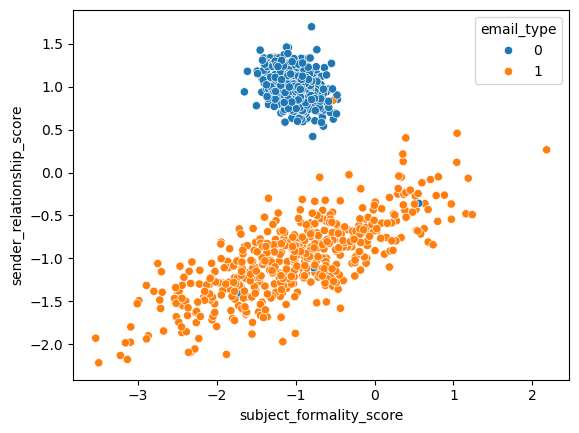

In [5]:
sns.scatterplot(x=df["subject_formality_score"], y=df["sender_relationship_score"], hue=df["email_type"])
plt.show()


In [6]:
X = df[["subject_formality_score", "sender_relationship_score"]].values
y = df[["email_type"]].values

In [7]:
X

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]], shape=(1000, 2))

In [8]:
y

array([[0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
    

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [11]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [12]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [13]:
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: torch.Size([800, 2])
X_test.shape: torch.Size([200, 2])
y_train.shape: torch.Size([800, 1])
y_test.shape: torch.Size([200, 1])


In [14]:
import torch.nn as nn

class ClassificationModel(nn.Module):

    def __init__(self):
        super().__init__()
        # 2 -> 5 -> 5 -> 1
        self.first_layer = nn.Linear(in_features=2, out_features=5)
        self.second_layer = nn.Linear(in_features=5, out_features=1)

    def forward(self, x:torch.tensor) -> torch.tensor:
        return self.second_layer(self.first_layer(x))


In [15]:
model = ClassificationModel()

In [16]:
loss_fn = nn.BCEWithLogitsLoss() # loss function
optimizer = torch.optim.SGD(params = model.parameters(), lr=0.01) # parameter function

In [17]:
def calculate_accuracy(y_test, y_pred):

    return (torch.eq(y_test, y_pred).sum() / len(y_test)) * 100

In [18]:
y_logits = model(X_test)[:5]
y_prediction_probs = torch.sigmoid(y_logits)

In [19]:
y_preds = torch.round(y_prediction_probs)

In [20]:
y_preds

tensor([[1.],
        [0.],
        [0.],
        [0.],
        [1.]], grad_fn=<RoundBackward0>)

In [21]:
calculate_accuracy(y_test[:5], y_preds)

tensor(20.)

In [22]:
torch.manual_seed(42)
epochs = 500

for epoch in range(epochs):

    model.train()

    y_logits = model(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits, y_train) # we choose BCEWithLogitLoss so we pass y_logits instead of y_pred

    accuracy = calculate_accuracy(y_test = y_train, y_pred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.inference_mode():
        
        test_logits = model(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_accuracy = calculate_accuracy(y_test, test_pred)

        if epoch % 5 == 0:

            print(f"Epoch: {epoch:<5}, Loss: {loss:2f}, Accuracy: {accuracy:2f}, Test Loss: {test_loss:2f}, Test Acc: {test_accuracy:2f}")
    
    

Epoch: 0    , Loss: 0.790556, Accuracy: 4.000000, Test Loss: 0.790371, Test Acc: 5.000000
Epoch: 5    , Loss: 0.769773, Accuracy: 6.750000, Test Loss: 0.768893, Test Acc: 8.000000
Epoch: 10   , Loss: 0.750055, Accuracy: 19.000000, Test Loss: 0.748522, Test Acc: 24.500000
Epoch: 15   , Loss: 0.731289, Accuracy: 46.375000, Test Loss: 0.729140, Test Acc: 52.999996
Epoch: 20   , Loss: 0.713375, Accuracy: 54.375000, Test Loss: 0.710646, Test Acc: 55.500000
Epoch: 25   , Loss: 0.696225, Accuracy: 55.750000, Test Loss: 0.692951, Test Acc: 57.000000
Epoch: 30   , Loss: 0.679762, Accuracy: 59.125000, Test Loss: 0.675976, Test Acc: 61.500000
Epoch: 35   , Loss: 0.663921, Accuracy: 67.250000, Test Loss: 0.659653, Test Acc: 71.500000
Epoch: 40   , Loss: 0.648643, Accuracy: 84.500000, Test Loss: 0.643922, Test Acc: 91.500000
Epoch: 45   , Loss: 0.633877, Accuracy: 96.125000, Test Loss: 0.628732, Test Acc: 97.500000
Epoch: 50   , Loss: 0.619579, Accuracy: 97.875000, Test Loss: 0.614036, Test Acc: 98

In [23]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.first_layer.weight.detach().numpy()       # shape (5,2)
    b1 = model.first_layer.bias.detach().numpy()         # shape (5,)
    W2 = model.second_layer.weight.detach().numpy()       # shape (1,5)
    b2 = model.second_layer.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

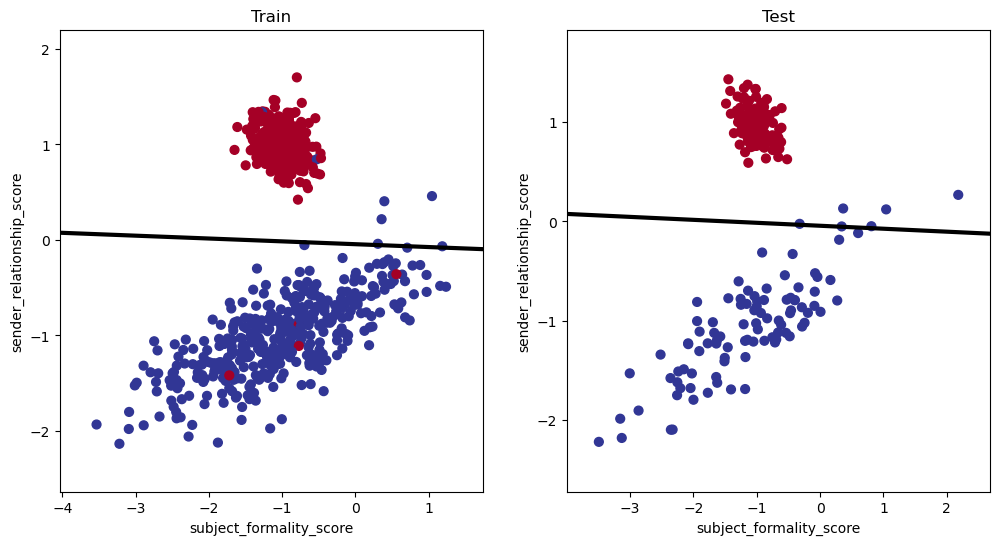

In [24]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model, X_test, y_test)

plt.show()